In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap


import warnings
warnings.filterwarnings('ignore')

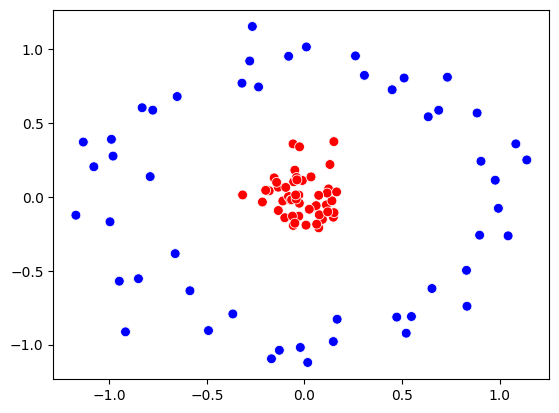

In [2]:
from sklearn.datasets import make_circles

X, y = make_circles(100, factor=.1, noise=.1)

sns.scatterplot(x=X[:, 0], y=X[:, 1], c=y, s=50, cmap='bwr')
plt.show()

# **SVC**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42)

classifier = SVC(kernel='linear')
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [4]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.45

#### SVC (Classification)
- **`C`**: Regularization (float, default=1.0)
    - Penalty for misclassification. Smaller `C` creates a wider margin (more simple/smooth), while larger `C` tries to classify all training points correctly (more complex/potential overfitting).
- **`kernel`**: Kernel type ('`linear`', '`poly`', '`rbf`', '`sigmoid`', '`precomputed`', default='`rbf`')
    - The mathematical function used to transform data. 
    - `rbf` is the default because it handles non-linear relationships by creating curved boundaries.
- **`degree`**: Poly kernel degree (int, default=3)
    - Only used when `kernel='poly'`. It represents the degree of the polynomial used to find the boundary.
- **`gamma`**: Kernel coefficient ('`scale`', '`auto`' or `float`, default='`scale`')
    - Defines the reach of a single training point's influence. `large` gamma means influence is local (wiggly boundary), `small` gamma means influence is global (smooth boundary).
- **`coef0`**: Independent term ('poly'/'sigmoid') (float, default=0.0)
    - Adjusts how much the model is influenced by high-degree vs. low-degree polynomials.
- **`shrinking`**: Use shrinking heuristic (bool, default=True)
    - Speeds up training by ignoring points that are unlikely to affect the decision boundary.
- **`probability`**: Enable probability estimates (bool, default=False)
    - Allows the use of `predict_proba()`. Note: This significantly slows down the training process.
- **`tol`**: Stopping tolerance (float, default=1e-3)
    - The precision level. The solver stops when the improvement is less than this value.
- **`cache_size`**: Kernel cache size in MB (float, default=200)
    - RAM assigned to the solver. Increasing this can speed up training on large datasets.
- **`class_weight`**: Weight for each class (dict or 'balanced', default=None)
    - Used to handle imbalanced datasets by giving more importance to minority classes.
- **`verbose`**: Verbose output (bool, default=False)
    - Enables console logging of the internal `libsvm` training process.
- **`max_iter`**: Solver iteration limit (int, default=-1)
    - Limits the number of iterations; `-1` means no limit (runs until convergence).
- **`decision_function_shape`**: 'ovr' (one-vs-rest) or 'ovo' (one-vs-one) (default='ovr')
    - Strategy for multi-class classification. `ovr` is usually preferred for efficiency.
- **`break_ties`**: Resolve ties in decision function (bool, default=False)
    - If `True`, it breaks ties between classes based on confidence values (only for `ovr`).
- **`random_state`**: Random seed (int, default=None)
    - Used for shuffling data during probability estimation to ensure reproducible results.

#### SVR (Regression)
- **`kernel`**: Kernel type (default='rbf')
    - Same as SVC; determines the shape of the regression line/surface.
- **`degree`**: Poly kernel degree (default=3)
    - Same as SVC; used only for polynomial regression.
- **`gamma`**: Kernel coefficient (default='scale')
    - Same as SVC; controls the smoothness of the regression surface.
- **`coef0`**: Independent term (default=0.0)
    - Same as SVC; shifts the polynomial curve.
- **`tol`**: Stopping tolerance (default=1e-3)
    - Same as SVC; defines when to stop optimizing the regression fit.
- **`C`**: Regularization (default=1.0)
    - Same as SVC; balances the trade-off between a smooth fit and minimizing training error.
- **`epsilon`**: Epsilon-tube size (float, default=0.1)
    - **Unique to SVR.** Specifies a "tube" around the predicted value where no penalty is given for errors. Smaller epsilon makes the model more sensitive to small errors.
- **`shrinking`**: Use shrinking heuristic (default=True)
    - Same optimization as SVC.
- **`cache_size`**: Kernel cache size in MB (default=200)
    - Same memory management as SVC.
- **`verbose`**: Verbose output (default=False)
    - Same logging as SVC.
- **`max_iter`**: Solver iteration limit (default=-1)
    - Same iteration control as SVC.


ValueError: x and y must be the same size

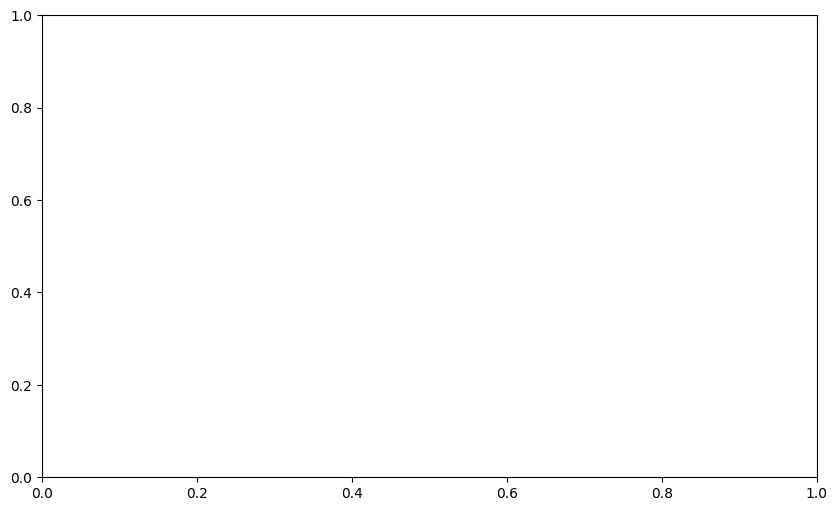

In [5]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Plot the actual testing data as blue dots
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Test Data')

# 2. To draw the curve properly, we must sort the X_test values 
# (Otherwise the line will zigzag back and forth between points)
X_test_sorted = np.sort(X_test, axis=0)

# 3. Ask your SVR model ('reg') to predict based on those sorted X values
y_pred_curve = reg.predict(X_test_sorted)

# 4. Plot the model's prediction curve as a solid red line
plt.plot(X_test_sorted, y_pred_curve, color='red', linewidth=3, label='SVR Prediction Curve')

# Add Labels, Title, and Legend
plt.title('Support Vector Regression (SVR) on Test Data')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Show the plot
plt.show()


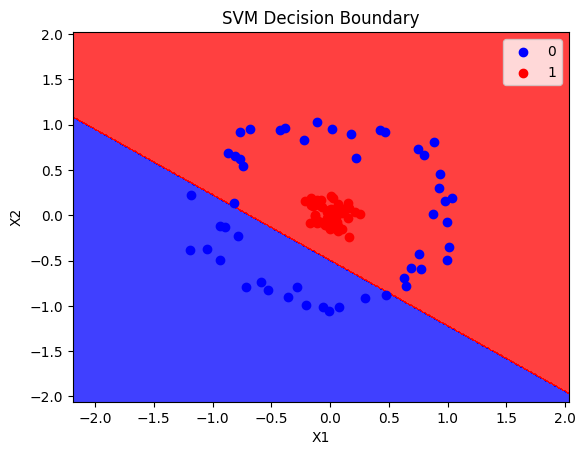

In [ ]:
plot_decision_boundary(X, y, classifier)

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

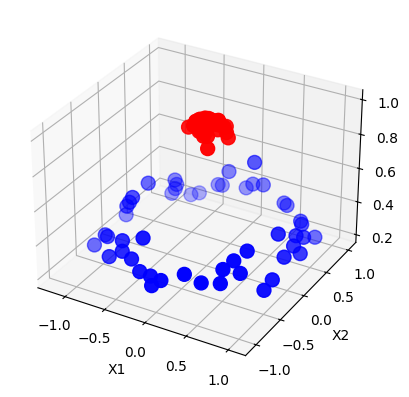

In [ ]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax


plot_3d_plot(X,y)

In [ ]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

accuracy_score(y_test, y_pred)      # as you can see by changing the rbf the accuracy increased to 100 %

1.0

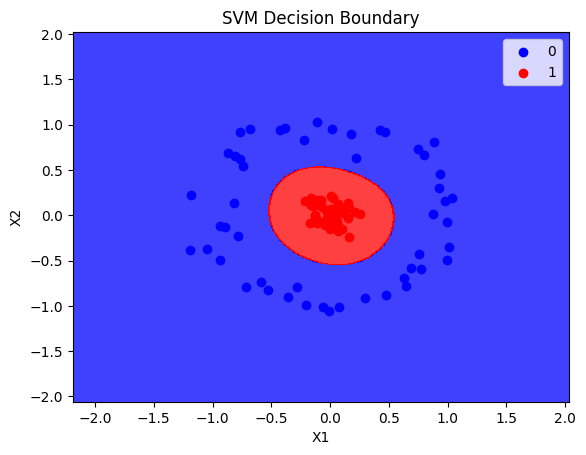

In [ ]:
plot_decision_boundary(X, y, rbf_classifier)

In [ ]:

poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

accuracy_score(y_test, y_pred)

1.0

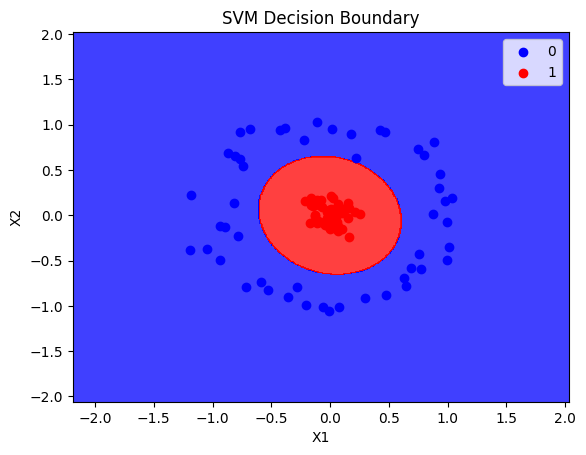

In [ ]:
plot_decision_boundary(X, y, poly_classifier)

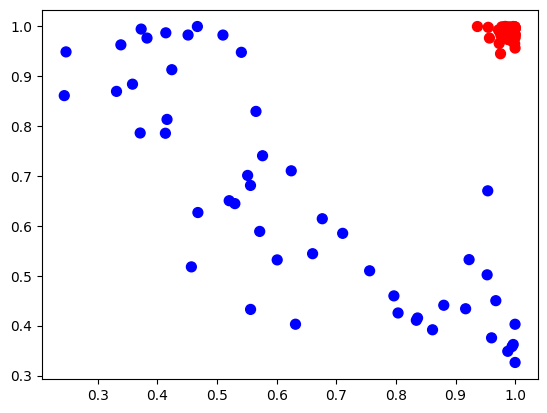

In [ ]:
X_new=np.exp(-(X**2))

plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')
plt.show()

# **SVR**

In [ ]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=300, n_features=4, n_targets=1, random_state=42)

X = pd.DataFrame(X, columns=[f"f {i}" for i in range(1, 5)])
y = pd.DataFrame(y, columns=['target'])

X

,f 1,f 2,f 3,f 4
0,0.857660,-0.019016,-0.159939,-1.002529
1,-0.688150,0.981765,2.252436,-0.324831
2,-1.200296,-0.474945,-0.334501,-0.653329
3,1.149273,-0.034988,-0.703176,1.770801
4,-0.544919,-0.037635,0.399136,1.103302
...,...,...,...,...
295,-1.415371,-0.342715,-0.420645,-0.802277
296,-0.517611,-0.016423,0.223788,1.188393
297,-0.637387,1.420504,1.189017,-0.570746
298,1.108183,0.612774,-1.039906,-1.053416


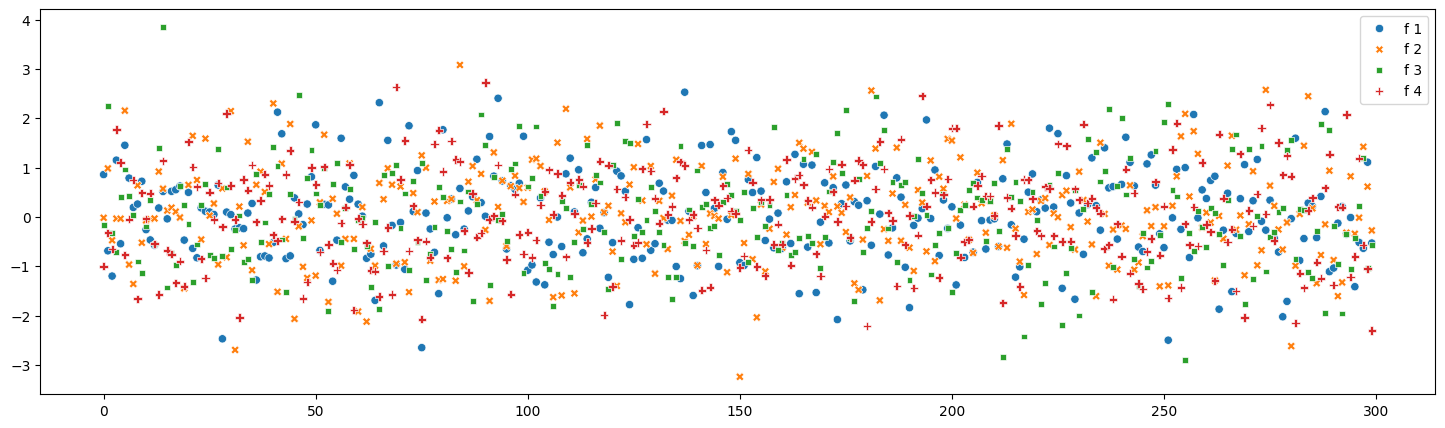

In [ ]:
plt.figure(figsize=(18, 5))
sns.scatterplot(X)
plt.show()

In [7]:
from sklearn.svm import SVR

reg = SVR(kernel='linear')
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))


-2.7637235695000775


In [8]:
reg = SVR(kernel='rbf')
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(r2_score(y_test, y_pred))


0.9411432269938077


In [9]:
reg = SVR(kernel='poly', degree=2)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(r2_score(y_test, y_pred))


0.8085483436067102


In [10]:
reg = SVR(kernel='sigmoid')
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(r2_score(y_test, y_pred))


-17.740586805834603
